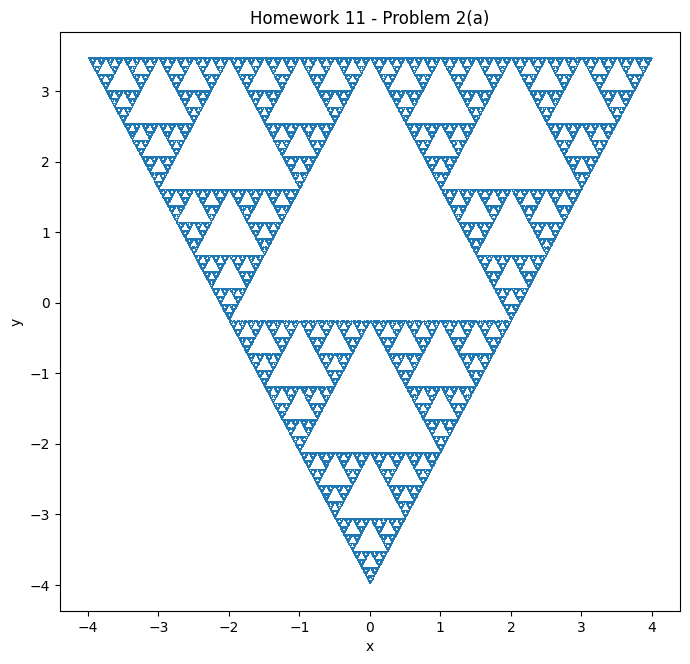

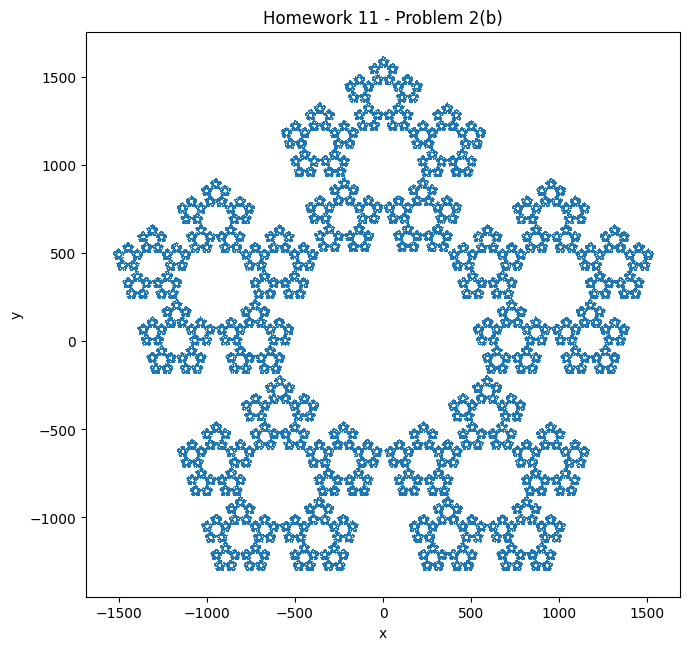

In [ ]:
# ###########################################################################
# Author: Edward E. Daisey
# Course: Modeling & Simulation of Complex Systems
# Title: Assignment 10 - Problem 2
# Date: 14th of April 2026
# ###########################################################################

################################### Overview ##################################
# Description:
#   This script solves the Chaos Game problem for two different parameter sets.
#   The iterated map is
#
#       x_(n+1) = a * x_n + X_i
#       y_(n+1) = a * y_n + Y_i
#
#   where one point P_i = (X_i, Y_i) is selected uniformly at random at each
#   iteration.
#
#   Part (a):
#       a   = 1/2
#       P_i = {(-2, sqrt(3)), (2, sqrt(3)), (0, -2)}
#
#   Part (b):
#       a   = 41/108
#       P_i = {(951, 309), (588, -809), (-588, -809), (-951, 309), (0, 1000)}
#
# Requirements:
#   (1) Use a random initial condition (x_0, y_0)
#   (2) Generate at least 2^18 points
#   (3) Ignore the first 100 iterates
#   (4) Plot the remaining points using the smallest possible marker size
#
# Output:
#   (1) Plot for Problem 2(a)
#   (2) Plot for Problem 2(b)
# ###########################################################################

# ############################ Imports ######################################
import math
import numpy as np
import matplotlib.pyplot as plt
# ###########################################################################


# ############################ Constants ####################################
numberOfPoints = 2 ** 18
burnInCount = 100
randomSeed = 605716

aPartA = 1.0 / 2.0
pointsPartA = np.array([
    [-2.0, math.sqrt(3.0)],
    [ 2.0, math.sqrt(3.0)],
    [ 0.0, -2.0]
])

aPartB = 41.0 / 108.0
pointsPartB = np.array([
    [ 951.0,  309.0],
    [ 588.0, -809.0],
    [-588.0, -809.0],
    [-951.0,  309.0],
    [   0.0, 1000.0]
])
# ###########################################################################


# ############################ Function 1 ###################################
# Name:
#   GenerateChaosGamePoints
#
# Purpose:
#   Generates Chaos Game iterates for a given contraction factor a and a given
#   set of points P_i.
#
# Input:
#   a              : Contraction factor.
#   pointSet       : Array of points P_i = (X_i, Y_i).
#   totalPoints    : Number of retained points to generate after burn-in.
#   burnIn         : Number of initial iterates to ignore.
#   seed           : Random seed for reproducibility.
#
# Output:
#   xValues        : Retained x-coordinates after burn-in.
#   yValues        : Retained y-coordinates after burn-in.
def GenerateChaosGamePoints(a, pointSet, totalPoints, burnIn, seed):
    randomGenerator = np.random.default_rng(seed)

    initialX = randomGenerator.uniform(-1.0, 1.0)
    initialY = randomGenerator.uniform(-1.0, 1.0)

    currentX = initialX
    currentY = initialY

    xValues = np.empty(totalPoints)
    yValues = np.empty(totalPoints)

    storeIndex = 0

    for iterationIndex in range(totalPoints + burnIn):
        randomPointIndex = randomGenerator.integers(len(pointSet))
        chosenPoint = pointSet[randomPointIndex]

        currentX = a * currentX + chosenPoint[0]
        currentY = a * currentY + chosenPoint[1]

        if iterationIndex >= burnIn:
            xValues[storeIndex] = currentX
            yValues[storeIndex] = currentY
            storeIndex += 1

    return xValues, yValues
# ###########################################################################


# ############################ Function 2 ###################################
# Name:
#   PlotChaosGame
#
# Purpose:
#   Plots the retained Chaos Game points using the smallest practical marker.
#
# Input:
#   xValues        : x-coordinates to plot.
#   yValues        : y-coordinates to plot.
#   plotTitle      : Title for the figure.
#
# Output:
#   Displays the requested Chaos Game plot.
def PlotChaosGame(xValues, yValues, plotTitle):
    plt.figure(figsize=(7.0, 7.0))
    plt.plot(xValues, yValues, ",")
    plt.gca().set_aspect("equal", adjustable="box")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(plotTitle)
    plt.tight_layout()
    plt.show()
# ###########################################################################


# ############################ Function 3 ###################################
# Name:
#   SolvePartA
#
# Purpose:
#   Solves and plots Assignment 10 Problem 2(a).
#
# Input:
#   None.
#
# Output:
#   Displays the Chaos Game plot for part (a).
def SolvePartA():
    xValues, yValues = GenerateChaosGamePoints(
        aPartA,
        pointsPartA,
        numberOfPoints,
        burnInCount,
        randomSeed
    )

    PlotChaosGame(xValues, yValues, "Assignment 10 - Problem 2(a)")
# ###########################################################################


# ############################ Function 4 ###################################
# Name:
#   SolvePartB
#
# Purpose:
#   Solves and plots Assignment 10 Problem 2(b).
#
# Input:
#   None.
#
# Output:
#   Displays the Chaos Game plot for part (b).
def SolvePartB():
    xValues, yValues = GenerateChaosGamePoints(
        aPartB,
        pointsPartB,
        numberOfPoints,
        burnInCount,
        randomSeed
    )

    PlotChaosGame(xValues, yValues, "Assignment 10 - Problem 2(b)")
# ###########################################################################


# ############################ Function 5 ###################################
# Name:
#   Main
#
# Purpose:
#   Runs both parts of Assignment 10 Problem 2.
#
# Input:
#   None.
#
# Output:
#   Displays the two required Chaos Game plots.
def Main():
    SolvePartA()
    SolvePartB()
# ###########################################################################


# ############################# Execution ###################################
Main()
# ###########################################################################